In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
url = 'https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/main/Dataset/D3.csv'
df = pd.read_csv(url)
print(df.head())

         X1        X2        X3         Y
0  0.000000  3.440000  0.440000  4.387545
1  0.040404  0.134949  0.888485  2.679650
2  0.080808  0.829899  1.336970  2.968490
3  0.121212  1.524848  1.785455  3.254065
4  0.161616  2.219798  2.233939  3.536375


In [22]:
X0 = df.values[:, 0]
X1 = df.values[:, 1]
X2 = df.values[:, 2]
Y = df.values[:, 3]
m = len(Y)

In [24]:
X00 = np.ones((m, 1))
X01 = X0.reshape(m, 1)
X0 = np.hstack((X00, X01))

X10 = np.ones((m, 1))
X11 = X1.reshape(m, 1)
X1 = np.hstack((X10, X11))

X20 = np.ones((m, 1))
X21 = X2.reshape(m, 1)
X2 = np.hstack((X20, X21))

In [26]:
theta = np.zeros(2)
def compute_cost(X, Y, theta):
    predictions = X.dot(theta)
    errors = np.subtract(predictions, Y)
    sqrErrors = np.square(errors)
    J = (1 / (2 * m)) * np.sum(sqrErrors)
    return J
X0cost = compute_cost(X0, Y, theta)
X1cost = compute_cost(X1, Y, theta)
X2cost = compute_cost(X2, Y, theta)
print(X0cost)
print(X1cost)
print(X2cost)

5.524438459196242
5.524438459196242
5.524438459196242


In [27]:
def gradient_descent(X, y, theta, alpha, iterations):
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X.dot(theta)
        errors = np.subtract(predictions, y)
        sum_delta = (alpha / m) * X.transpose().dot(errors)
        theta -= sum_delta
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history

In [38]:
iterations = 2000
alpha = 0.02

In [39]:
theta0, cost_history0 = gradient_descent(X0, Y, theta, alpha, iterations)
theta1, cost_history1 = gradient_descent(X1, Y, theta, alpha, iterations)
theta2, cost_history2 = gradient_descent(X2, Y, theta, alpha, iterations)
print(theta0)
print(theta1)
print(theta2)
print(cost_history0)
print(cost_history1)
print(cost_history2)

[ 2.87115249 -0.52037625]
[ 2.87115249 -0.52037625]
[ 2.87115249 -0.52037625]
[2.67137485 2.60704059 2.55466531 ... 0.98499311 0.98499311 0.98499311]
[7.94588806 7.75703447 7.60451737 ... 3.59936609 3.59936609 3.59936609]
[4.37025781 4.34016513 4.31559527 ... 3.62945113 3.62945113 3.62945113]


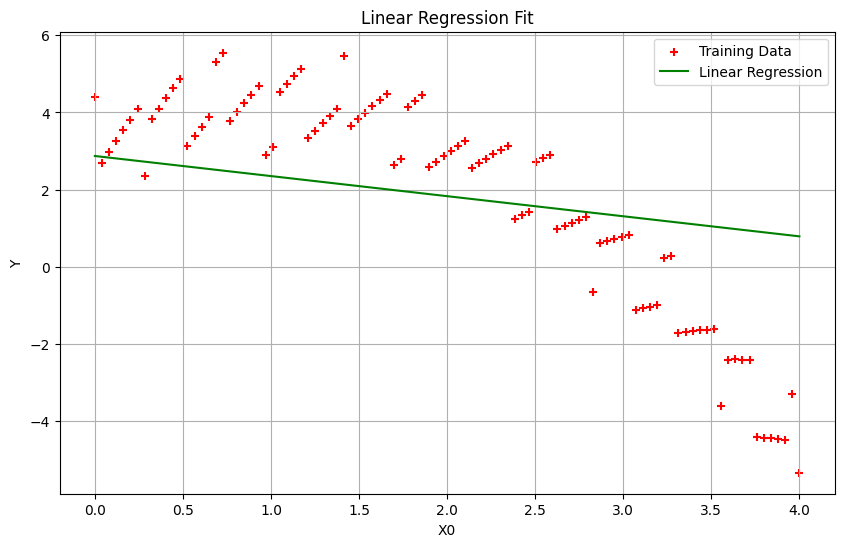

In [57]:
plt.scatter(X0[:, 1], Y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X0[:, 1], X0.dot(theta0), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X0')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

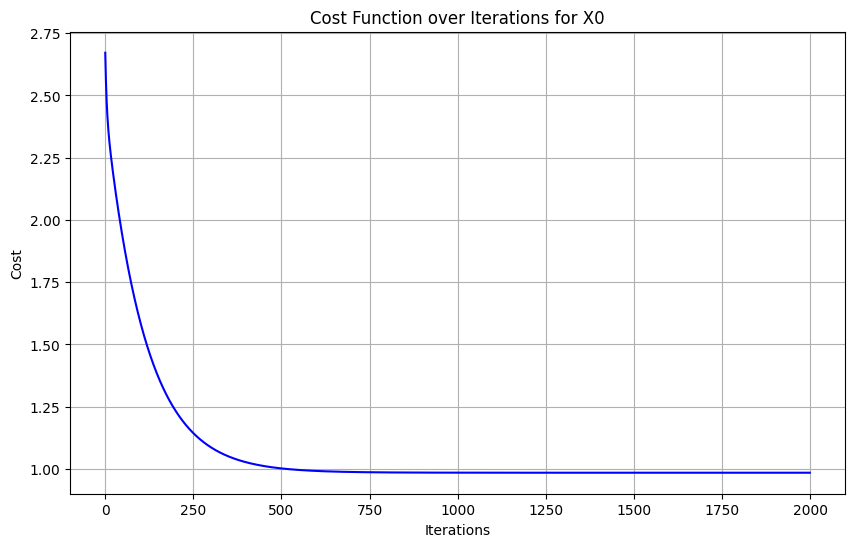

In [59]:
plt.plot(range(iterations), cost_history0, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations for X0')
plt.show()

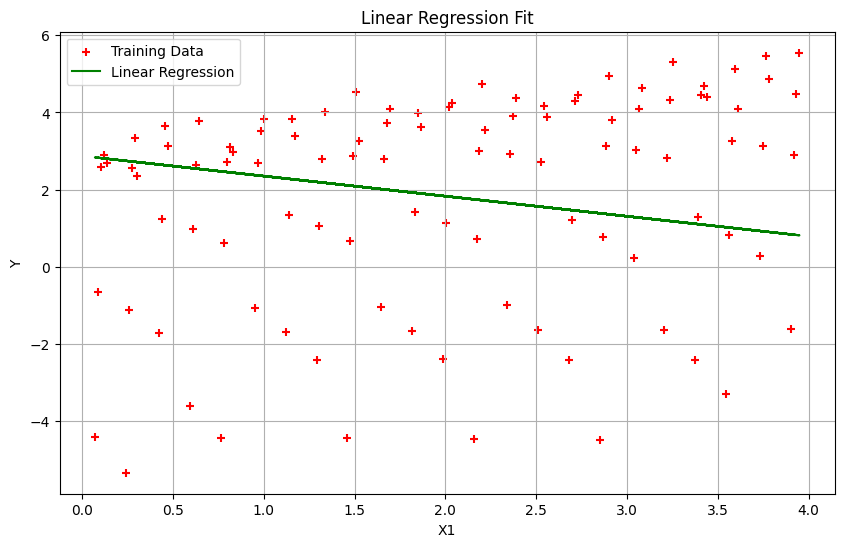

In [33]:
plt.scatter(X1[:, 1], Y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X1[:, 1], X1.dot(theta1), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X1')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

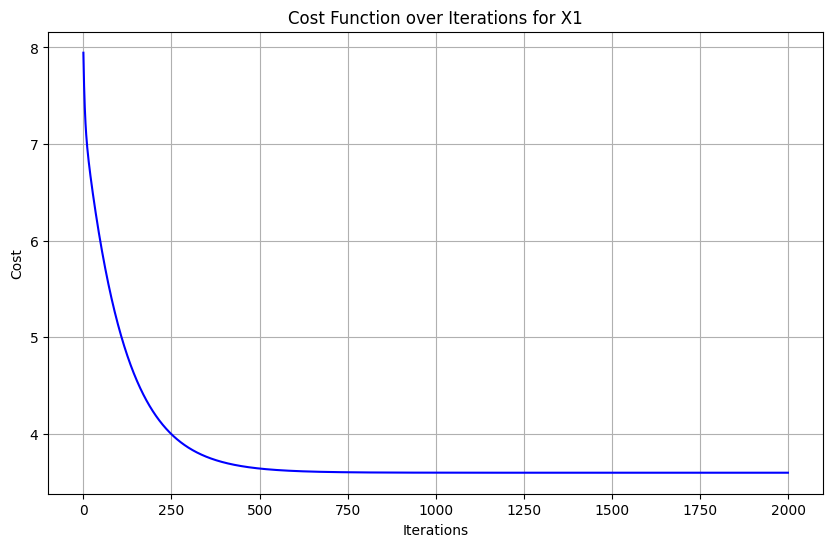

In [58]:
plt.plot(range(iterations), cost_history1, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations for X1')
plt.show()

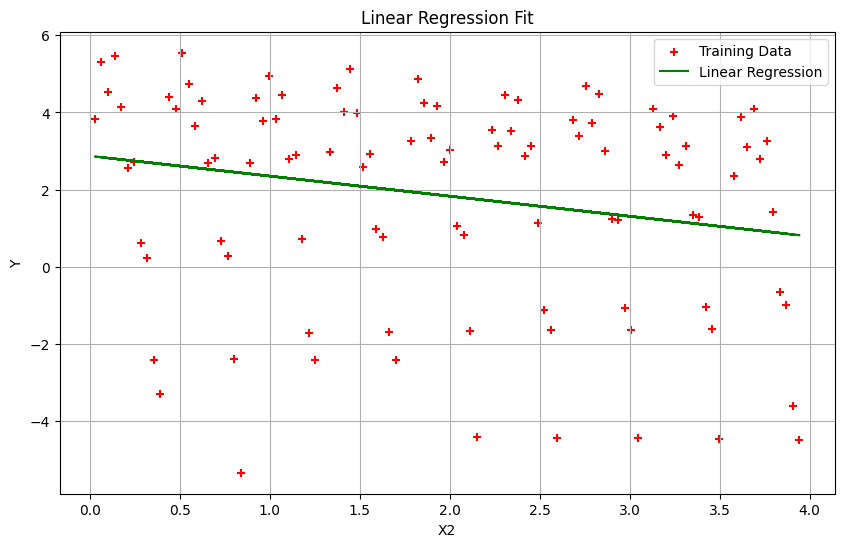

In [34]:
plt.scatter(X2[:, 1], Y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X2[:, 1], X2.dot(theta2), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X2')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

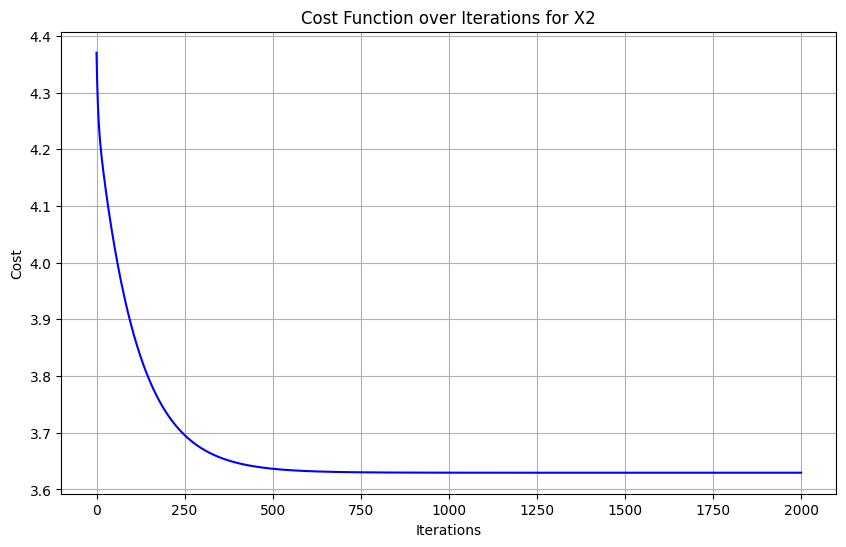

In [60]:
plt.plot(range(iterations), cost_history2, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations for X2')
plt.show()

In [46]:
iterations_multi = 2000
alpha_multi = 0.01

In [47]:

X_multi = df.values[:, 0:3]
X_multi = np.c_[np.ones(len(Y)), X_multi]

theta_multi = np.zeros(4)


theta_multi, cost_history_multi = gradient_descent(X_multi, Y, theta_multi, alpha_multi, iterations_multi)

print(f"theta: {theta_multi}")
print(f"cost history: {cost_history_multi}")


theta: [ 4.60784132 -1.90393905  0.64927931 -0.16206885]
cost history: [5.21542243 4.97171977 4.7765543  ... 0.76514569 0.76509252 0.76503946]


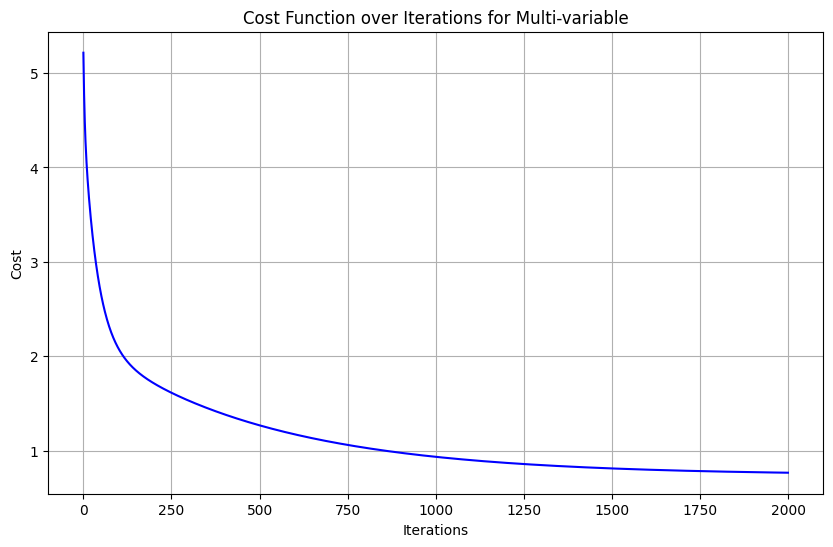

In [50]:
plt.plot(range(iterations_multi), cost_history_multi, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations for Multi-variable')
plt.show()

In [61]:
example0 = np.array([1, 1, 1])
temp_example = np.insert(example0, 0, 1)
prediction0 = temp_example.dot(theta_multi)

example1 = np.array([2, 0, 4])
temp_example = np.insert(example1, 0, 1)
prediction1 = temp_example.dot(theta_multi)

example2 = np.array([3, 2, 1])
temp_example = np.insert(example2, 0, 1)
prediction2 = temp_example.dot(theta_multi)

print(f"Input features: {example0}")
print(f"Predicted Y for example1: {prediction0}")

print(f"Input features: {example1}")
print(f"Predicted Y for example2: {prediction1}")

print(f"Input features: {example2}")
print(f"Predicted Y for example3: {prediction2}")

Input features: [1 1 1]
Predicted Y for example1: 3.1911127254543454
Input features: [2 0 4]
Predicted Y for example2: 0.151687810222343
Input features: [3 2 1]
Predicted Y for example3: 0.03251393005171713
